# Multi-turn Conversation Activation Analysis
Analysis dimensions: conversational behavior / activation-correctness relationship / activation dynamics / layer contribution comparison

## 0. Dependencies and Imports

In [1]:
import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from collections import Counter, defaultdict
from pathlib import Path
from sklearn.metrics import roc_auc_score

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Dependencies imported successfully')

✅ Dependencies imported successfully


## 1. Data Loading

Three loading modes are supported:
- **A**: Specify a folder and automatically load all `.json` files
- **B**: Specify a file list
- **C**: Paste a JSON list directly (for small-scale debugging)

In [2]:
# ============================================================
# Modify settings here to switch the loading mode
# ============================================================

LOAD_MODE = 'files'   # 'folder' | 'files' | 'inline'
BALANCE_CLASSES = True  # True: downsample to keep correct/incorrect balanced

DATA_FOLDER = './logs'          # Used when LOAD_MODE='folder'
# DATA_FILES  = ['logs/math/sharded-at0-ut0/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl']
DATA_FILES = ['logs/actions/sharded-at0-ut0/sharded-at0-ut0_actions_meta-llama_Llama-3.1-8B-Instruct.jsonl']
# DATA_FILES  = ['logs/math/sharded-at0-ut0/sharded-at0-ut0_math_Qwen_Qwen2.5-14B-Instruct.jsonl',
#                'logs/math/sharded-at0-ut0/(add_v2)sharded-at0-ut0_math_Qwen_Qwen2.5-14B-Instruct.jsonl']
# DATA_FILES  = ['logs/code/sharded-at0-ut0/sharded-at0-ut0_code_Qwen_Qwen2.5-14B-Instruct.jsonl']
# DATA_FILES  = ['logs/math/sharded-at0-ut0/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl']   # Used when LOAD_MODE='files'

# When LOAD_MODE='inline', paste your JSON list into RAW_DATA
RAW_DATA = [
    # Paste your JSON objects here
]

# ============================================================
def load_records():
    records = []
    if LOAD_MODE == 'folder':
        paths = glob.glob(os.path.join(DATA_FOLDER, '*.json'))
        for p in paths:
            with open(p, 'r', encoding='utf-8') as f:
                obj = json.load(f)
                # Support either a single dict or a list
                records.extend(obj if isinstance(obj, list) else [obj])
    elif LOAD_MODE == 'files':
        for p in DATA_FILES:
            with open(p, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        records.append(json.loads(line))
    elif LOAD_MODE == 'inline':
        records = RAW_DATA
    else:
        raise ValueError(f'Unknown LOAD_MODE: {LOAD_MODE}')
    return records

records = load_records()
print(f'✅ Loaded {len(records)} conversation records in total')

✅ Loaded 105 conversation records in total


## 2. Data Parsing -> Structured DataFrame

In [3]:
def parse_record(rec):
    """Extract all fields required for analysis from a single record."""
    trace = rec.get('trace', [])
    ar    = rec.get('activation_result', {})

    # ---------- Conversational behavior statistics ----------
    response_types = []
    answer_attempts = []
    num_turns = 0          # Number of user turns
    num_assistant = 0
    for entry in trace:
        role = entry.get('role', '')
        if role == 'user':
            num_turns += 1
        elif role == 'assistant':
            num_assistant += 1
        elif role == 'log':
            content = entry.get('content', {})
            if isinstance(content, dict):
                if content.get('type') == 'system-verification':
                    rt = content.get('response', {}).get('response_type', 'unknown')
                    response_types.append(rt)
                elif content.get('type') == 'answer-evaluation':
                    answer_attempts.append({
                        'exact_answer': content.get('exact_answer'),
                        'is_correct':   content.get('is_correct'),
                        'score':        content.get('score', 0.0),
                    })

    rt_counter = Counter(response_types)

    # ---------- Activation values ----------
    delta_scores      = ar.get('delta_scores', [])        # shape: [num_shards]
    cumulative_scores = ar.get('cumulative_scores', [])   # shape: [num_shards+1]
    delta_per_layer   = ar.get('delta_per_layer', [])     # shape: [num_shards, num_layers]
    cumulative_per_layer = ar.get('cumulative_per_layer', [])  # shape: [num_shards+1, num_layers]

    num_layers = len(delta_per_layer[0]) if delta_per_layer else 0
    num_shards = len(delta_scores)

    # First answer attempt vs. final attempt
    first_attempt = answer_attempts[0]  if answer_attempts else {}
    last_attempt  = answer_attempts[-1] if answer_attempts else {}

    # Canonical correctness rule: score == 0 -> incorrect, otherwise correct.
    raw_score = rec.get('score', 0.0)
    try:
        final_score = float(raw_score)
    except (TypeError, ValueError):
        final_score = 0.0
    is_correct_by_score = (final_score != 0.0)

    return {
        # Metadata
        'conv_id':       rec.get('conv_id'),
        'task':          rec.get('task'),
        'task_id':       rec.get('task_id'),
        'conv_type':     rec.get('conv_type'),
        'assistant_model': rec.get('assistant_model'),

        # Outcomes
        'is_correct_raw': rec.get('is_correct'),
        'is_correct':    is_correct_by_score,
        'final_score':   final_score,
        'first_correct': first_attempt.get('is_correct'),
        'num_answer_attempts': len(answer_attempts),

        # Conversational behavior
        'num_user_turns':     num_turns,
        'num_assistant_turns': num_assistant,
        'num_clarifications': rt_counter.get('clarification', 0),
        'num_discussions':    rt_counter.get('discussion', 0),
        'num_answer_resp':    rt_counter.get('answer_attempt', 0),
        'response_types_seq': response_types,   # Full sequence for order analysis

        # Activation values (global)
        'delta_scores':           delta_scores,
        'cumulative_scores':      cumulative_scores,
        'delta_per_layer':        delta_per_layer,
        'cumulative_per_layer':   cumulative_per_layer,
        'num_shards':             num_shards,
        'num_layers':             num_layers

        # Derived activation features
        ,'mean_delta':      np.mean(delta_scores) if delta_scores else np.nan
        ,'max_delta':       np.max(delta_scores)  if delta_scores else np.nan
        ,'final_cumulative': cumulative_scores[-1] if cumulative_scores else np.nan
        ,'peak_delta_shard': int(np.argmax(delta_scores)) if delta_scores else np.nan
    }

parsed = [parse_record(r) for r in records]
df = pd.DataFrame(parsed)
print(f'✅ Parsing completed: {len(df)} rows, {len(df.columns)} columns')
df[['conv_id','task','is_correct','num_user_turns','num_clarifications',
    'mean_delta','final_cumulative']].head(10)

✅ Parsing completed: 105 rows, 26 columns


,conv_id,task,is_correct,num_user_turns,num_clarifications,mean_delta,final_cumulative
0,69f90f0e5afea93b4afad0ba,actions,True,5,0,NaN,NaN
1,69f90f155afea93b4afad0bb,actions,False,6,0,NaN,NaN
2,69f90f1b5afea93b4afad0bc,actions,True,7,0,NaN,NaN
3,69f90f245afea93b4afad0bd,actions,True,7,0,NaN,NaN
4,69f90f2d5afea93b4afad0be,actions,True,8,0,NaN,NaN
5,69f90f385afea93b4afad0bf,actions,True,4,0,NaN,NaN
6,69f90f405afea93b4afad0c0,actions,False,6,0,NaN,NaN
7,69f90f475afea93b4afad0c1,actions,False,6,0,NaN,NaN
8,69f90f575afea93b4afad0c2,actions,False,10,0,NaN,NaN
9,69f90f605afea93b4afad0c3,actions,True,6,0,NaN,NaN


In [4]:
# Quick statistics overview (original, unbalanced)
print('=== Basic Statistics (Original) ===')

s = df['is_correct']
correct_cnt = s.eq(True).sum()
incorrect_cnt = s.eq(False).sum()
missing_cnt = s.isna().sum()
valid_cnt = correct_cnt + incorrect_cnt

print(f'Total conversations            : {len(df)}')
print(f'Correct / Incorrect / Missing  : {correct_cnt} / {incorrect_cnt} / {missing_cnt}')
print(f'Accuracy (valid only)          : {correct_cnt / valid_cnt:.2%}' if valid_cnt else 'Accuracy (valid only)          : N/A')
print(f'Avg. user turns                : {df.num_user_turns.mean():.3f}')
print(f'Avg. assistant turns           : {df.num_assistant_turns.mean():.3f}')
print(f'Avg. user turns by correctness : {df.groupby("is_correct").num_user_turns.mean().to_dict()}')

=== Basic Statistics (Original) ===
Total conversations            : 105
Correct / Incorrect / Missing  : 61 / 44 / 0
Accuracy (valid only)          : 58.10%
Avg. user turns                : 5.381
Avg. assistant turns           : 5.381
Avg. user turns by correctness : {False: 5.386363636363637, True: 5.377049180327869}



=== Normal Fit on num_user_turns ===
Correct   : n=40, mu=5.1250, sigma=1.2848
Incorrect : n=63, mu=5.7937, sigma=1.4828


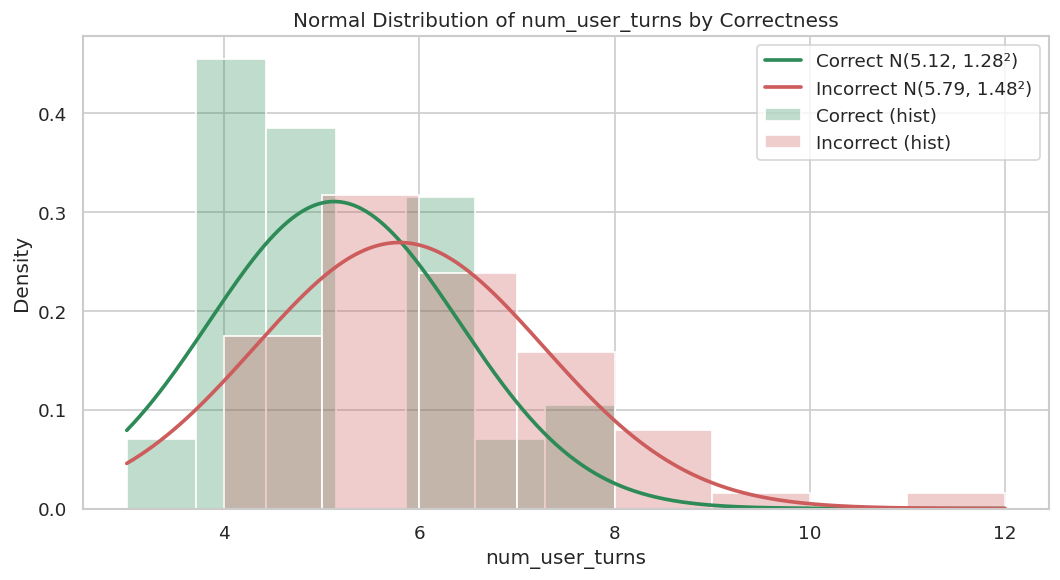

In [8]:
# ===== Normal distribution of num_user_turns for correct vs incorrect =====
correct_turns = df.loc[df['is_correct'] == True, 'num_user_turns'].dropna().astype(float)
incorrect_turns = df.loc[df['is_correct'] == False, 'num_user_turns'].dropna().astype(float)

def fit_normal(x: pd.Series):
    if len(x) == 0:
        return np.nan, np.nan
    mu = float(np.mean(x))
    sigma = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    return mu, sigma

mu_c, sigma_c = fit_normal(correct_turns)
mu_i, sigma_i = fit_normal(incorrect_turns)

print('\n=== Normal Fit on num_user_turns ===')
print(f'Correct   : n={len(correct_turns)}, mu={mu_c:.4f}, sigma={sigma_c:.4f}')
print(f'Incorrect : n={len(incorrect_turns)}, mu={mu_i:.4f}, sigma={sigma_i:.4f}')

# Plot histogram + fitted normal curves
plt.figure(figsize=(9, 5))

if len(correct_turns) > 0:
    sns.histplot(correct_turns, stat='density', bins='auto', alpha=0.30, color='#2E8B57', label='Correct (hist)')
if len(incorrect_turns) > 0:
    sns.histplot(incorrect_turns, stat='density', bins='auto', alpha=0.30, color='#CD5C5C', label='Incorrect (hist)')

# Build x-axis range from available data
all_vals = pd.concat([correct_turns, incorrect_turns], ignore_index=True)
if len(all_vals) > 0:
    x_min, x_max = float(all_vals.min()), float(all_vals.max())
    if x_min == x_max:
        x_min -= 1.0
        x_max += 1.0
    x = np.linspace(x_min, x_max, 400)

    def normal_pdf(x, mu, sigma):
        if not np.isfinite(mu) or not np.isfinite(sigma):
            return np.full_like(x, np.nan, dtype=float)
        if sigma <= 1e-12:
            return np.zeros_like(x, dtype=float)
        return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    y_c = normal_pdf(x, mu_c, sigma_c)
    y_i = normal_pdf(x, mu_i, sigma_i)

    if np.isfinite(y_c).any():
        plt.plot(x, y_c, color='#2E8B57', linewidth=2.2, label=f'Correct N({mu_c:.2f}, {sigma_c:.2f}²)')
    if np.isfinite(y_i).any():
        plt.plot(x, y_i, color='#CD5C5C', linewidth=2.2, label=f'Incorrect N({mu_i:.2f}, {sigma_i:.2f}²)')

plt.title('Normal Distribution of num_user_turns by Correctness')
plt.xlabel('num_user_turns')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

=== Range-Filtered Normal Fit on num_user_turns ===
Filter range used: [3.00, 8.00]
Correct   : 40/40 kept, mu=5.1250, sigma=1.2848
Incorrect : 61/63 kept, mu=5.6393, sigma=1.1977


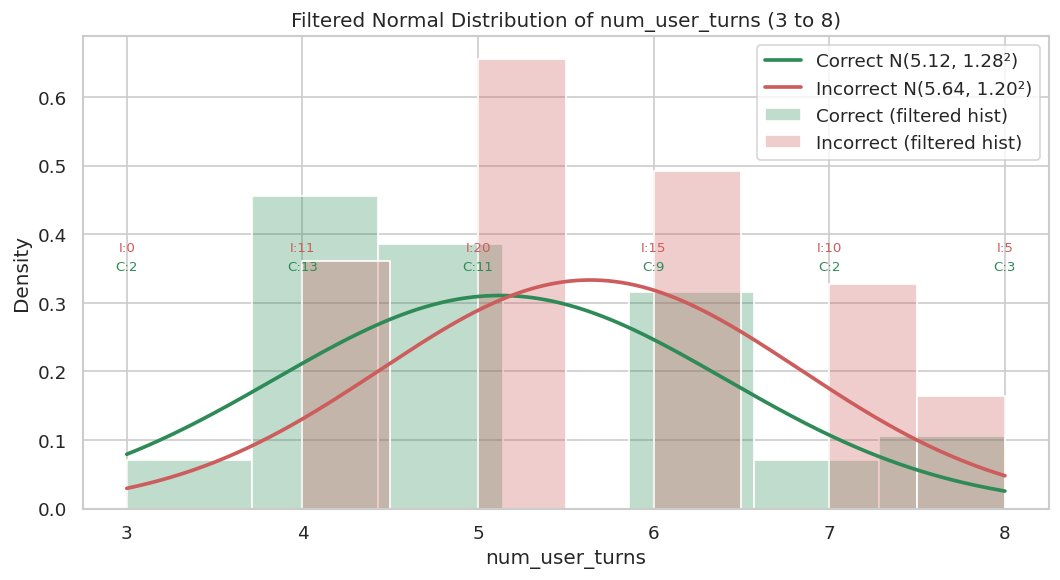

In [9]:
# ===== Range-filtered normal fit and plot (recommended: from start to 8) =====
print('=== Range-Filtered Normal Fit on num_user_turns ===')

all_turns = df['num_user_turns'].dropna().astype(float)

if len(all_turns) == 0:
    print('No num_user_turns data available.')
else:
    # Suggested by data shape + your idea: [min_turn, 8] with safety clamp to observed max
    fit_lo = float(all_turns.min())
    fit_hi = float(min(8.0, all_turns.max()))

    if fit_hi <= fit_lo:
        fit_hi = float(all_turns.max())

    print(f'Filter range used: [{fit_lo:.2f}, {fit_hi:.2f}]')

    correct_all = df.loc[df['is_correct'] == True, 'num_user_turns'].dropna().astype(float)
    incorrect_all = df.loc[df['is_correct'] == False, 'num_user_turns'].dropna().astype(float)

    correct_f = correct_all[correct_all.between(fit_lo, fit_hi, inclusive='both')]
    incorrect_f = incorrect_all[incorrect_all.between(fit_lo, fit_hi, inclusive='both')]

    def fit_normal_local(x: pd.Series):
        if len(x) == 0:
            return np.nan, np.nan
        mu = float(np.mean(x))
        sigma = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        return mu, sigma

    mu_cf, sigma_cf = fit_normal_local(correct_f)
    mu_if, sigma_if = fit_normal_local(incorrect_f)

    print(f'Correct   : {len(correct_f)}/{len(correct_all)} kept, mu={mu_cf:.4f}, sigma={sigma_cf:.4f}')
    print(f'Incorrect : {len(incorrect_f)}/{len(incorrect_all)} kept, mu={mu_if:.4f}, sigma={sigma_if:.4f}')

    def normal_pdf_local(x, mu, sigma):
        if not np.isfinite(mu) or not np.isfinite(sigma):
            return np.full_like(x, np.nan, dtype=float)
        if sigma <= 1e-12:
            return np.zeros_like(x, dtype=float)
        return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    plt.figure(figsize=(9, 5))

    if len(correct_f) > 0:
        sns.histplot(correct_f, stat='density', bins='auto', alpha=0.30, color='#2E8B57', label='Correct (filtered hist)')
    if len(incorrect_f) > 0:
        sns.histplot(incorrect_f, stat='density', bins='auto', alpha=0.30, color='#CD5C5C', label='Incorrect (filtered hist)')

    x = np.linspace(fit_lo, fit_hi, 400)
    y_cf = normal_pdf_local(x, mu_cf, sigma_cf)
    y_if = normal_pdf_local(x, mu_if, sigma_if)

    if np.isfinite(y_cf).any():
        plt.plot(x, y_cf, color='#2E8B57', linewidth=2.2, label=f'Correct N({mu_cf:.2f}, {sigma_cf:.2f}²)')
    if np.isfinite(y_if).any():
        plt.plot(x, y_if, color='#CD5C5C', linewidth=2.2, label=f'Incorrect N({mu_if:.2f}, {sigma_if:.2f}²)')

    # Annotate per-turn sample counts for this filtered range
    integer_turns = np.arange(int(np.floor(fit_lo)), int(np.ceil(fit_hi)) + 1)
    c_counts = correct_f.round().astype(int).value_counts().to_dict()
    i_counts = incorrect_f.round().astype(int).value_counts().to_dict()

    y_top = 0.0
    if np.isfinite(y_cf).any():
        y_top = max(y_top, float(np.nanmax(y_cf)))
    if np.isfinite(y_if).any():
        y_top = max(y_top, float(np.nanmax(y_if)))
    y_base = y_top * 1.03 if y_top > 0 else 0.02

    for t in integer_turns:
        c_n = int(c_counts.get(t, 0))
        i_n = int(i_counts.get(t, 0))
        if c_n == 0 and i_n == 0:
            continue
        # Slight vertical staggering to reduce overlap
        plt.text(t, y_base, f'C:{c_n}', color='#2E8B57', ha='center', va='bottom', fontsize=8)
        plt.text(t, y_base * 1.08, f'I:{i_n}', color='#CD5C5C', ha='center', va='bottom', fontsize=8)

    plt.title(f'Filtered Normal Distribution of num_user_turns ({fit_lo:.0f} to {fit_hi:.0f})')
    plt.xlabel('num_user_turns')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# Rebuild df for downstream analysis
print('=== Rebuild df for downstream analysis ===')

# Start from full parsed data if available (avoid carrying previous temporary filters)
if 'parsed' in globals():
    df_base = pd.DataFrame(parsed).copy()
else:
    df_base = df.copy()

# If range variables exist, keep consistency with the filtered distribution fitting
use_range_filter = ('fit_lo' in globals()) and ('fit_hi' in globals())

if use_range_filter:
    lo, hi = float(fit_lo), float(fit_hi)
    mask = df_base['is_correct'].isin([True, False]) & df_base['num_user_turns'].between(lo, hi, inclusive='both')
    print(f'Using range filter: [{lo:.2f}, {hi:.2f}]')
else:
    mask = df_base['is_correct'].isin([True, False])
    print('No range filter found, using all valid correct/incorrect rows.')

df_filtered = df_base[mask].copy()

balance_classes = bool(globals().get('BALANCE_CLASSES', False))
if balance_classes:
    sampled_parts = []
    turn_stats = []

    for turn, grp in df_filtered.groupby('num_user_turns', sort=True):
        grp_c = grp[grp['is_correct'].eq(True)]
        grp_i = grp[grp['is_correct'].eq(False)]
        n_cross = min(len(grp_c), len(grp_i))

        if n_cross > 0:
            sampled_parts.append(grp_c.sample(n=n_cross, random_state=42))
            sampled_parts.append(grp_i.sample(n=n_cross, random_state=42))

        turn_stats.append({
            'num_user_turns': int(turn),
            'correct_raw': int(len(grp_c)),
            'incorrect_raw': int(len(grp_i)),
            'sampled_each': int(n_cross),
            'sampled_total': int(2 * n_cross),
        })

    if sampled_parts:
        df = (
            pd.concat(sampled_parts, ignore_index=True)
            .sample(frac=1.0, random_state=42)
            .reset_index(drop=True)
        )
        print('Class balancing enabled: per-turn min-cross downsampling applied.')
    else:
        df = df_filtered.copy().reset_index(drop=True)
        print('Class balancing enabled, but no turn has both classes; fallback to unbalanced data.')

    turn_balance_df = pd.DataFrame(turn_stats).sort_values('num_user_turns').reset_index(drop=True)
    print('Per-turn balance stats (raw and sampled):')
    display(turn_balance_df)
else:
    df = df_filtered.copy().reset_index(drop=True)
    print('Class balancing disabled; using original class sizes.')

print(f'Rebuilt df rows         : {len(df)}')
print(f'Correct / Incorrect     : {df["is_correct"].eq(True).sum()} / {df["is_correct"].eq(False).sum()}')
print(f'num_user_turns min/max  : {df["num_user_turns"].min()} / {df["num_user_turns"].max()}')

df[['conv_id', 'is_correct', 'num_user_turns']].head(10)

=== Rebuild df for downstream analysis ===
Using range filter: [3.00, 8.00]
Class balancing enabled: per-turn min-cross downsampling applied.
Per-turn balance stats (raw and sampled):


,num_user_turns,correct_raw,incorrect_raw,sampled_each,sampled_total
0,3,2,0,0,0
1,4,13,11,11,22
2,5,11,20,11,22
3,6,9,15,9,18
4,7,2,10,2,4
5,8,3,5,3,6


Rebuilt df rows         : 72
Correct / Incorrect     : 36 / 36
num_user_turns min/max  : 4 / 8


,conv_id,is_correct,num_user_turns
0,69d5304eeb124e2b49d5a399,True,4
1,69d52ea2eb124e2b49d5a390,True,7
2,69d5293beb124e2b49d5a37b,False,4
3,69d539b1eb124e2b49d5a3c4,True,4
4,69d534cfeb124e2b49d5a3b0,True,5
5,69d532e5eb124e2b49d5a3a6,True,6
6,69d53847eb124e2b49d5a3c0,True,4
7,69d535f0eb124e2b49d5a3b5,False,5
8,69d5257feb124e2b49d5a366,False,4
9,69d53372eb124e2b49d5a3a8,False,6


---
## 3. Conversational Behavior Analysis
### 3.1 Response Type Distribution

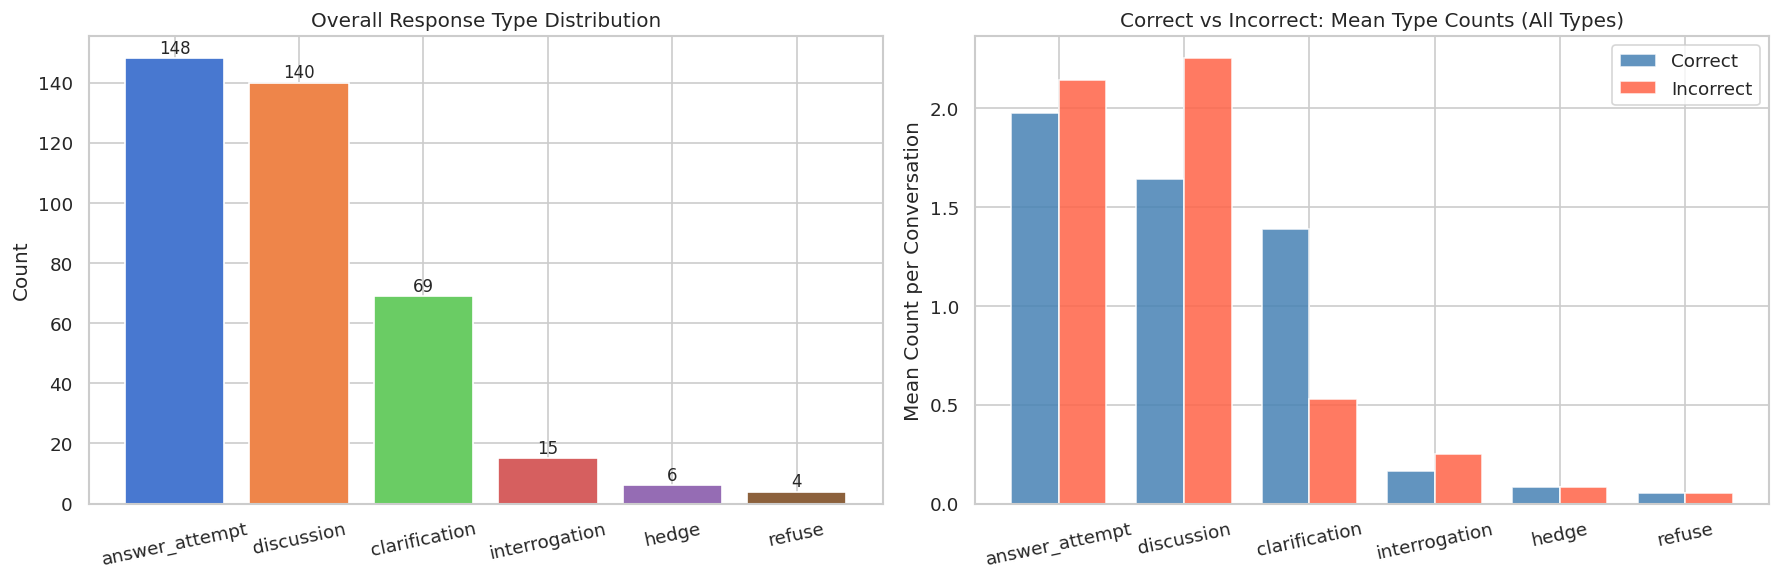

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Left: overall response type distribution ----
all_types = [t for seq in df.response_types_seq for t in seq]
type_counts = Counter(all_types)
labels, values = zip(*sorted(type_counts.items(), key=lambda x: -x[1]))

bars = axes[0].bar(labels, values, color=sns.color_palette('muted', len(labels)))
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Overall Response Type Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=12)

# ---- Right: behavior comparison between correct and incorrect conversations ----
# Use the same full type list as the left chart, then compute per-conversation mean counts.
type_order = list(labels)

type_count_rows = []
for seq in df['response_types_seq']:
    c = Counter(seq)
    type_count_rows.append({t: c.get(t, 0) for t in type_order})

type_count_df = pd.DataFrame(type_count_rows)
type_count_df['is_correct'] = df['is_correct'].values

group_means = type_count_df.groupby('is_correct')[type_order].mean()

correct_means = group_means.loc[True] if True in group_means.index else pd.Series(0.0, index=type_order)
incorrect_means = group_means.loc[False] if False in group_means.index else pd.Series(0.0, index=type_order)

x = np.arange(len(type_order))
w = 0.38
axes[1].bar(x - w/2, correct_means.values,   w, label='Correct', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, incorrect_means.values, w, label='Incorrect', color='tomato',    alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(type_order, rotation=12)
axes[1].set_title('Correct vs Incorrect: Mean Type Counts (All Types)')
axes[1].set_ylabel('Mean Count per Conversation')
axes[1].legend()

plt.tight_layout()
# plt.savefig('analyse/fig1_behavior_distribution.png', bbox_inches='tight')
plt.show()

In [12]:
def get_answer_seq(seq):
    """Extract the response sequence up to and including the first answer_attempt."""
    seq_with_attempt = []
    for t in seq:
        seq_with_attempt.append(t)
        if t == 'answer_attempt':
            break
    return tuple(seq_with_attempt)

df['answer_seq'] = df['response_types_seq'].apply(get_answer_seq)

# Separate sequences by correctness
correct_seqs = df[df['is_correct'] == True]['answer_seq']
incorrect_seqs = df[df['is_correct'] == False]['answer_seq']

correct_counts = Counter(correct_seqs)
incorrect_counts = Counter(incorrect_seqs)

# Top-10 for correct answers
correct_df = pd.DataFrame([
    {'sequence': ' -> '.join(k) if k else '(direct)', 'count': v}
    for k, v in correct_counts.most_common(10)
])
print('Top-10 most common response paths leading to CORRECT answers:')
print(correct_df.to_string(index=False))

print('\n' + '='*80 + '\n')

# Top-10 for incorrect answers
incorrect_df = pd.DataFrame([
    {'sequence': ' -> '.join(k) if k else '(direct)', 'count': v}
    for k, v in incorrect_counts.most_common(10)
])
print('Top-10 most common response paths leading to INCORRECT answers:')
print(incorrect_df.to_string(index=False))

Top-10 most common response paths leading to CORRECT answers:
                                                                                        sequence  count
                                                      discussion -> discussion -> answer_attempt      4
                               clarification -> clarification -> clarification -> answer_attempt      3
                                        discussion -> discussion -> discussion -> answer_attempt      3
                                                                    discussion -> answer_attempt      2
                                                clarification -> clarification -> answer_attempt      2
                                            refuse -> discussion -> discussion -> answer_attempt      1
                               interrogation -> interrogation -> clarification -> answer_attempt      1
                                     clarification -> discussion -> discussion -> answer_attempt      1
di

In [13]:
def get_answer_seq(seq):
    """Extract the complete response sequence (entire conversation path)."""
    if not isinstance(seq, (list, tuple)):
        return tuple()
    return tuple(seq)

# Build full response-path sequence for each conversation
df['answer_seq'] = df['response_types_seq'].apply(get_answer_seq)

# Analyze per turn count (do not mix all turns together)
turn_col = 'num_user_turns'
valid_df = df[df['is_correct'].isin([True, False]) & df[turn_col].notna()].copy()

if valid_df.empty:
    print('No valid rows for turn-wise path analysis.')
else:
    top_k = 10
    turns = sorted(valid_df[turn_col].unique())

    for turn in turns:
        turn_df = valid_df[valid_df[turn_col] == turn]

        correct_seqs = turn_df[turn_df['is_correct'] == True]['answer_seq']
        incorrect_seqs = turn_df[turn_df['is_correct'] == False]['answer_seq']

        correct_counts = Counter(correct_seqs)
        incorrect_counts = Counter(incorrect_seqs)

        print(f"\n{'='*90}")
        print(f"Turn = {int(turn)} | Total={len(turn_df)} | Correct={len(correct_seqs)} | Incorrect={len(incorrect_seqs)}")
        print(f"{'='*90}")

        # Top-K for correct answers in this turn
        correct_df = pd.DataFrame([
            {'sequence': ' -> '.join(k) if k else '(direct)', 'count': v}
            for k, v in correct_counts.most_common(top_k)
        ])
        print('Top response paths leading to CORRECT answers:')
        if correct_df.empty:
            print('(none)')
        else:
            print(correct_df.to_string(index=False))

        print('')

        # Top-K for incorrect answers in this turn
        incorrect_df = pd.DataFrame([
            {'sequence': ' -> '.join(k) if k else '(direct)', 'count': v}
            for k, v in incorrect_counts.most_common(top_k)
        ])
        print('Top response paths leading to INCORRECT answers:')
        if incorrect_df.empty:
            print('(none)')
        else:
            print(incorrect_df.to_string(index=False))


Turn = 4 | Total=22 | Correct=11 | Incorrect=11
Top response paths leading to CORRECT answers:
                                                          sequence  count
 clarification -> clarification -> clarification -> answer_attempt      3
      discussion -> discussion -> answer_attempt -> answer_attempt      2
              refuse -> discussion -> discussion -> answer_attempt      1
  discussion -> answer_attempt -> answer_attempt -> answer_attempt      1
       clarification -> discussion -> discussion -> answer_attempt      1
          discussion -> discussion -> discussion -> answer_attempt      1
    discussion -> clarification -> clarification -> answer_attempt      1
clarification -> clarification -> answer_attempt -> answer_attempt      1

Top response paths leading to INCORRECT answers:
                                                          sequence  count
              discussion -> discussion -> discussion -> discussion      3
clarification -> clarification -> answer

Probability of final correctness by first answer-attempt stage:


is_correct,N,Correct (%),Incorrect (%)
attempt_stage,,,
earliest,10,20.00,80.00
early,10,50.00,50.00
midway,19,47.37,52.63
late,15,93.33,6.67
latest,9,66.67,33.33


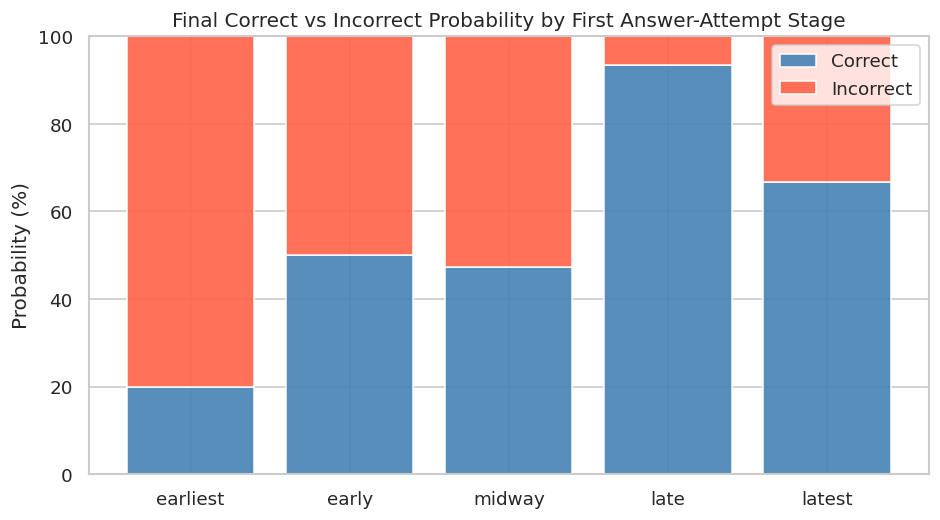

In [14]:
# First answer-attempt stage vs final correctness probability
def first_answer_progress_pct(seq):
    """Return where the first answer_attempt happens as % of conversation progress."""
    if not isinstance(seq, (list, tuple)) or len(seq) == 0:
        return np.nan
    try:
        idx = list(seq).index('answer_attempt')
    except ValueError:
        return np.nan
    return (idx / len(seq)) * 100.0

df['first_answer_progress_pct'] = df['response_types_seq'].apply(first_answer_progress_pct)

stage_labels = ['earliest', 'early', 'midway', 'late', 'latest']
stage_bins = [0, 20, 40, 60, 80, 100]

df_stage = df[df['is_correct'].isin([True, False]) & df['first_answer_progress_pct'].notna()].copy()
df_stage['attempt_stage'] = pd.cut(
    df_stage['first_answer_progress_pct'],
    bins=stage_bins,
    labels=stage_labels,
    include_lowest=True,
    right=True
 )

prob_df = (
    df_stage.groupby('attempt_stage', observed=False)['is_correct']
    .value_counts(normalize=True)
    .rename('prob_pct')
    .mul(100)
    .reset_index()
 )

stage_prob = (
    prob_df.pivot(index='attempt_stage', columns='is_correct', values='prob_pct')
    .rename(columns={True: 'Correct (%)', False: 'Incorrect (%)'})
    .reindex(stage_labels)
    .fillna(0)
 )

stage_n = df_stage['attempt_stage'].value_counts().reindex(stage_labels).fillna(0).astype(int)

stage_result = stage_prob.copy()
stage_result['N'] = stage_n.values
stage_result = stage_result[['N', 'Correct (%)', 'Incorrect (%)']]

print('Probability of final correctness by first answer-attempt stage:')
display(stage_result.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(stage_labels))
ax.bar(x, stage_result['Correct (%)'], label='Correct', color='steelblue', alpha=0.9)
ax.bar(
    x,
    stage_result['Incorrect (%)'],
    bottom=stage_result['Correct (%)'],
    label='Incorrect',
    color='tomato',
    alpha=0.9
)
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_ylim(0, 100)
ax.set_ylabel('Probability (%)')
ax.set_title('Final Correct vs Incorrect Probability by First Answer-Attempt Stage')
ax.legend()
plt.tight_layout()
plt.show()